<a href="https://colab.research.google.com/github/Betphet234/Nonprofit-Health-Finance-Analysis/blob/main/nonprofit_health_org_finances.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()


Saving nonprofit-health-org-finances.csv to nonprofit-health-org-finances.csv


In [3]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.head()

,ein,org_name,state,fiscal_year,total_revenue,total_expenses,highest_exec_compensation
0,941340523,Kaiser Foundation Health Plan Inc,CA,2023,7.510131e+10,7.435600e+10,NaN
1,941105628,Kaiser Foundation Hospitals,CA,2023,3.278736e+10,3.065070e+10,12835.0
2,900656139,Mass General Brigham Incorporated And Affiliat...,MA,2023,2.273322e+10,2.158441e+10,2841349.0
3,383952644,Mayo Clinic Group Return,MN,2023,1.397074e+10,1.377896e+10,4309705.0
4,133783732,Healthfirst Phsp Inc,NY,2023,1.208568e+10,1.192440e+10,NaN


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 18829
Columns: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18829 entries, 0 to 18828
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ein                        18829 non-null  int64  
 1   org_name                   18829 non-null  object 
 2   state                      18821 non-null  object 
 3   fiscal_year                18829 non-null  int64  
 4   total_revenue              18788 non-null  float64
 5   total_expenses             18739 non-null  float64
 6   highest_exec_compensation  1057 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.0+ MB


In [5]:
df.describe(include="all")

,ein,org_name,state,fiscal_year,total_revenue,total_expenses,highest_exec_compensation
count,1.882900e+04,18829,18821,18829.000000,1.878800e+04,1.873900e+04,1.057000e+03
unique,NaN,18595,54,NaN,NaN,NaN,NaN
top,NaN,Corewell Health,CA,NaN,NaN,NaN,NaN
freq,NaN,30,1791,NaN,NaN,NaN,NaN
mean,5.219019e+08,NaN,NaN,2022.910139,8.213913e+07,8.016898e+07,6.585822e+05
std,2.711354e+08,NaN,NaN,0.912986,7.656720e+08,7.480596e+08,1.099149e+06
min,1.021148e+07,NaN,NaN,2011.000000,-5.092579e+07,1.000000e+00,0.000000e+00
25%,2.723916e+08,NaN,NaN,2023.000000,1.945008e+05,1.812185e+05,2.372120e+05
50%,4.727969e+08,NaN,NaN,2023.000000,8.379730e+05,7.847760e+05,3.684700e+05
75%,8.153814e+08,NaN,NaN,2023.000000,8.029355e+06,7.918656e+06,7.158740e+05


In [6]:
df.columns


Index(['ein', 'org_name', 'state', 'fiscal_year', 'total_revenue',
       'total_expenses', 'highest_exec_compensation'],
      dtype='object')

In [7]:
money_cols = [
    "total_revenue",
    "total_expenses",
    "highest_exec_compensation"
]

for col in money_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["fiscal_year"] = pd.to_numeric(df["fiscal_year"], errors="coerce")

In [8]:
df_2023 = df[df["fiscal_year"] == 2023].copy()

print("2023 rows:", df_2023.shape[0])
df_2023.head()

2023 rows: 16190


,ein,org_name,state,fiscal_year,total_revenue,total_expenses,highest_exec_compensation
0,941340523,Kaiser Foundation Health Plan Inc,CA,2023,7.510131e+10,7.435600e+10,NaN
1,941105628,Kaiser Foundation Hospitals,CA,2023,3.278736e+10,3.065070e+10,12835.0
2,900656139,Mass General Brigham Incorporated And Affiliat...,MA,2023,2.273322e+10,2.158441e+10,2841349.0
3,383952644,Mayo Clinic Group Return,MN,2023,1.397074e+10,1.377896e+10,4309705.0
4,133783732,Healthfirst Phsp Inc,NY,2023,1.208568e+10,1.192440e+10,NaN


In [9]:
df_2023["surplus"] = df_2023["total_revenue"] - df_2023["total_expenses"]

df_2023["margin"] = np.where(
    df_2023["total_revenue"] != 0,
    df_2023["surplus"] / df_2023["total_revenue"],
    np.nan
)

df_2023["exec_comp_to_revenue"] = np.where(
    df_2023["total_revenue"] != 0,
    df_2023["highest_exec_compensation"] / df_2023["total_revenue"],
    np.nan
)

df_2023.head()

,ein,org_name,state,fiscal_year,total_revenue,total_expenses,highest_exec_compensation,surplus,margin,exec_comp_to_revenue
0,941340523,Kaiser Foundation Health Plan Inc,CA,2023,7.510131e+10,7.435600e+10,NaN,7.453029e+08,0.009924,NaN
1,941105628,Kaiser Foundation Hospitals,CA,2023,3.278736e+10,3.065070e+10,12835.0,2.136665e+09,0.065167,3.914618e-07
2,900656139,Mass General Brigham Incorporated And Affiliat...,MA,2023,2.273322e+10,2.158441e+10,2841349.0,1.148816e+09,0.050535,1.249866e-04
3,383952644,Mayo Clinic Group Return,MN,2023,1.397074e+10,1.377896e+10,4309705.0,1.917848e+08,0.013728,3.084807e-04
4,133783732,Healthfirst Phsp Inc,NY,2023,1.208568e+10,1.192440e+10,NaN,1.612749e+08,0.013344,NaN


In [10]:
total_revenue = df_2023["total_revenue"].sum()
total_expenses = df_2023["total_expenses"].sum()
total_surplus = df_2023["surplus"].sum()
overall_margin = total_surplus / total_revenue

overall_summary = pd.DataFrame({
    "metric": [
        "Total organizations",
        "Total revenue",
        "Total expenses",
        "Total surplus",
        "Overall margin"
    ],
    "value": [
        df_2023.shape[0],
        total_revenue,
        total_expenses,
        total_surplus,
        overall_margin
    ]
})

overall_summary

,metric,value
0,Total organizations,1.619000e+04
1,Total revenue,1.436579e+12
2,Total expenses,1.401646e+12
3,Total surplus,3.482870e+10
4,Overall margin,2.424419e-02


In [11]:
state_summary = (
    df_2023
    .groupby("state", dropna=False)
    .agg(
        organizations=("ein", "count"),
        total_revenue=("total_revenue", "sum"),
        total_expenses=("total_expenses", "sum"),
        total_surplus=("surplus", "sum"),
        avg_revenue=("total_revenue", "mean"),
        median_revenue=("total_revenue", "median"),
        avg_margin=("margin", "mean"),
        median_margin=("margin", "median")
    )
    .reset_index()
)

state_summary["overall_state_margin"] = (
    state_summary["total_surplus"] / state_summary["total_revenue"]
)

state_summary = state_summary.sort_values("total_revenue", ascending=False)

state_summary.head(10)

,state,organizations,total_revenue,total_expenses,total_surplus,avg_revenue,median_revenue,avg_margin,median_margin,overall_state_margin
4,CA,1563,2.302216e+11,2.240766e+11,6.144812e+09,1.475780e+08,734953.5,-8.552291,0.030797,0.026691
35,NY,1312,1.413812e+11,1.383035e+11,3.075140e+09,1.081723e+08,2088814.0,-0.070675,0.009067,0.021751
45,TX,864,6.468493e+10,6.093328e+10,3.751490e+09,7.512768e+07,733093.0,-0.064679,0.031400,0.057996
20,MA,448,6.458979e+10,6.319823e+10,1.391556e+09,1.444962e+08,2291782.0,-0.021608,0.007643,0.021545
36,OH,681,6.051123e+10,5.860583e+10,1.904935e+09,8.911816e+07,1058690.0,-0.070127,0.027192,0.031481
39,PA,900,5.764552e+10,5.701803e+10,6.266652e+08,6.412183e+07,1399910.0,0.014181,0.020847,0.010871
15,IL,501,5.247369e+10,5.088641e+10,1.587296e+09,1.049474e+08,1000750.0,0.037683,0.036849,0.030249
50,WA,351,5.203230e+10,5.305355e+10,-1.021247e+09,1.482402e+08,862411.0,-0.041783,0.016344,-0.019627
9,FL,719,5.089795e+10,4.783139e+10,3.047133e+09,7.098738e+07,805274.0,-1.579238,0.035164,0.059867
23,MI,486,5.017640e+10,4.923829e+10,9.384008e+08,1.034565e+08,1211170.0,-0.039363,0.023500,0.018702


In [13]:
top_revenue_orgs = (
    df_2023
    .sort_values("total_revenue", ascending=False)
    [[
        "ein",
        "org_name",
        "state",
        "total_revenue",
        "total_expenses",
        "surplus",
        "margin",
        "highest_exec_compensation"
    ]]
    .head(25)
)

top_revenue_orgs

,ein,org_name,state,total_revenue,total_expenses,surplus,margin,highest_exec_compensation
0,941340523,Kaiser Foundation Health Plan Inc,CA,7.510131e+10,7.435600e+10,7.453029e+08,0.009924,NaN
1,941105628,Kaiser Foundation Hospitals,CA,3.278736e+10,3.065070e+10,2.136665e+09,0.065167,12835.0
2,900656139,Mass General Brigham Incorporated And Affiliat...,MA,2.273322e+10,2.158441e+10,1.148816e+09,0.050535,2841349.0
3,383952644,Mayo Clinic Group Return,MN,1.397074e+10,1.377896e+10,1.917848e+08,0.013728,4309705.0
4,133783732,Healthfirst Phsp Inc,NY,1.208568e+10,1.192440e+10,1.612749e+08,0.013344,NaN
5,611740292,Corewell Health,MI,1.037425e+10,1.022959e+10,1.446614e+08,0.013944,30538.0
6,133957095,The New York And Presbyterian Hospital,NY,1.025451e+10,9.755790e+09,4.987218e+08,0.048634,NaN
7,941196203,Dignity Health,AZ,9.914543e+09,1.012669e+10,-2.121440e+08,-0.021397,NaN
8,510216586,Providence Health & Services Washington,WA,9.778289e+09,1.012214e+10,-3.438501e+08,-0.035165,NaN
9,942854057,Ihc Health Services Inc,UT,9.638579e+09,8.793797e+09,8.447813e+08,0.087646,NaN


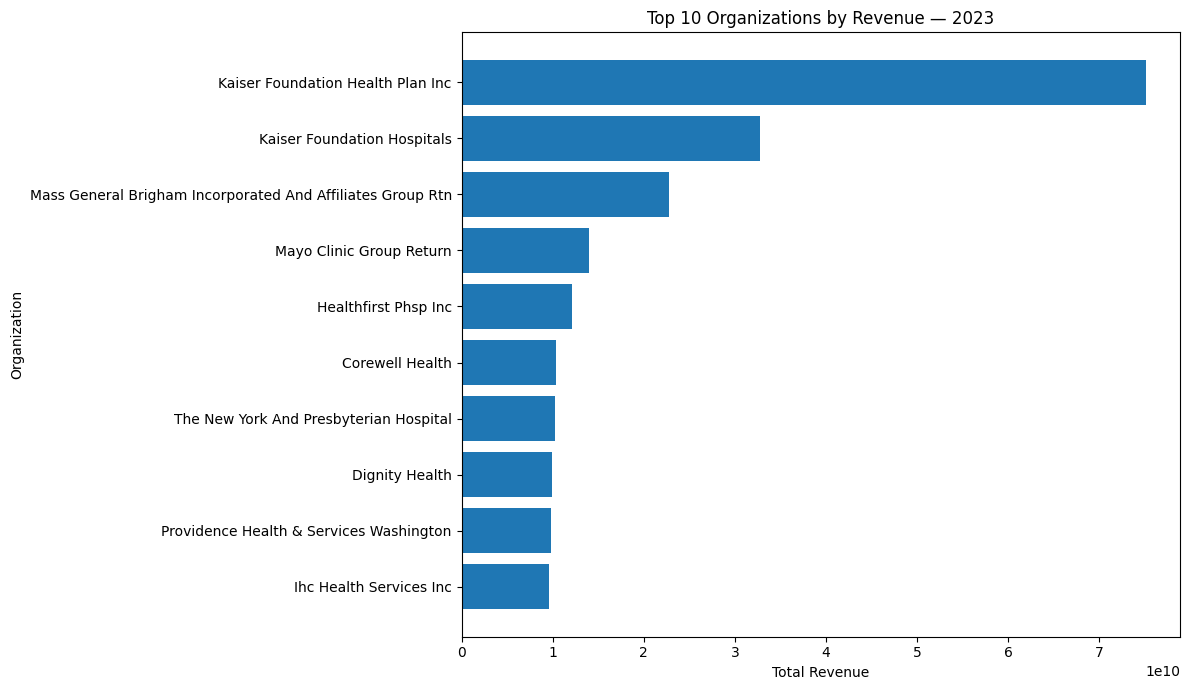

In [14]:
top_orgs_chart = top_revenue_orgs.head(10).copy()

plt.figure(figsize=(12, 7))
plt.barh(top_orgs_chart["org_name"], top_orgs_chart["total_revenue"])
plt.title("Top 10 Organizations by Revenue — 2023")
plt.xlabel("Total Revenue")
plt.ylabel("Organization")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
revenue_concentration = df_2023.sort_values(
    "total_revenue",
    ascending=False
).copy()

revenue_concentration["cumulative_revenue"] = revenue_concentration["total_revenue"].cumsum()
revenue_concentration["cumulative_revenue_share"] = (
    revenue_concentration["cumulative_revenue"] / revenue_concentration["total_revenue"].sum()
)

revenue_concentration[[
    "org_name",
    "state",
    "total_revenue",
    "cumulative_revenue_share"
]].head(25)

,org_name,state,total_revenue,cumulative_revenue_share
0,Kaiser Foundation Health Plan Inc,CA,7.510131e+10,0.052278
1,Kaiser Foundation Hospitals,CA,3.278736e+10,0.075101
2,Mass General Brigham Incorporated And Affiliat...,MA,2.273322e+10,0.090926
3,Mayo Clinic Group Return,MN,1.397074e+10,0.100651
4,Healthfirst Phsp Inc,NY,1.208568e+10,0.109063
5,Corewell Health,MI,1.037425e+10,0.116285
6,The New York And Presbyterian Hospital,NY,1.025451e+10,0.123423
7,Dignity Health,AZ,9.914543e+09,0.130325
8,Providence Health & Services Washington,WA,9.778289e+09,0.137131
9,Ihc Health Services Inc,UT,9.638579e+09,0.143841


In [16]:
df.columns

Index(['ein', 'org_name', 'state', 'fiscal_year', 'total_revenue',
       'total_expenses', 'highest_exec_compensation'],
      dtype='object')

In [19]:
top_surplus_orgs = (
    df_2023
    .sort_values("surplus", ascending=False)
    [[
        "ein",
        "org_name",
        "state",
        "total_revenue",
        "total_expenses",
        "surplus",
        "margin"
    ]]
    .head(25)
)

top_surplus_orgs

,ein,org_name,state,total_revenue,total_expenses,surplus,margin
1,941105628,Kaiser Foundation Hospitals,CA,3.278736e+10,3.065070e+10,2.136665e+09,0.065167
12,133971298,Nyu Langone Hospitals,NY,8.868511e+09,7.561158e+09,1.307353e+09,0.147415
2,900656139,Mass General Brigham Incorporated And Affiliat...,MA,2.273322e+10,2.158441e+10,1.148816e+09,0.050535
55,591726273,Orlando Health Inc,FL,4.224072e+09,3.288157e+09,9.359153e+08,0.221567
9,942854057,Ihc Health Services Inc,UT,9.638579e+09,8.793797e+09,8.447813e+08,0.087646
10,450233470,Banner Health,AZ,9.479574e+09,8.672349e+09,8.072253e+08,0.085154
30,351955872,Indiana University Health Inc,IN,5.752063e+09,4.970388e+09,7.816748e+08,0.135895
0,941340523,Kaiser Foundation Health Plan Inc,CA,7.510131e+10,7.435600e+10,7.453029e+08,0.009924
50,314394942,Ohiohealth Corporation Grant Riverside Doctors...,OH,4.522460e+09,3.824187e+09,6.982730e+08,0.154401
16,741152597,Memorial Hermann Health System,TX,7.581409e+09,6.952310e+09,6.290998e+08,0.082979


In [20]:
largest_loss_orgs = (
    df_2023
    .sort_values("surplus", ascending=True)
    [[
        "ein",
        "org_name",
        "state",
        "total_revenue",
        "total_expenses",
        "surplus",
        "margin"
    ]]
    .head(25)
)

largest_loss_orgs

,ein,org_name,state,total_revenue,total_expenses,surplus,margin
23,362169147,Advocate Health And Hospitals Corporation,IL,6.903058e+09,7.524374e+09,-621316124.0,-0.090006
762,205392766,Community Physicians Of Indiana Inc,IN,4.200054e+08,9.382342e+08,-518228806.0,-1.233862
173,236291113,Geisinger Clinic,PA,1.746719e+09,2.206776e+09,-460056928.0,-0.263384
251,351747218,Indiana University Health Care Associates Inc,IN,1.283406e+09,1.735478e+09,-452071682.0,-0.352244
386,571004971,Prisma Health University Medical Group,SC,8.569191e+08,1.292682e+09,-435763368.0,-0.508523
444,593259553,Orlando Health Medical Group Inc,FL,7.427572e+08,1.169125e+09,-426367640.0,-0.574034
304,650267668,Baptist Health Of South Florida Inc,FL,1.102432e+09,1.478456e+09,-376023645.0,-0.341085
8,510216586,Providence Health & Services Washington,WA,9.778289e+09,1.012214e+10,-343850065.0,-0.035165
56,910511770,Kaiser Foundation Health Plan Of Washington,WA,4.197890e+09,4.536064e+09,-338173964.0,-0.080558
1302,873651176,Coh Holdco Inc,CA,1.473658e+08,4.622600e+08,-314894141.0,-2.136819


In [21]:
exec_comp_orgs = (
    df_2023
    .dropna(subset=["highest_exec_compensation"])
    .sort_values("highest_exec_compensation", ascending=False)
    [[
        "ein",
        "org_name",
        "state",
        "total_revenue",
        "highest_exec_compensation",
        "exec_comp_to_revenue"
    ]]
    .head(25)
)

exec_comp_orgs

,ein,org_name,state,total_revenue,highest_exec_compensation,exec_comp_to_revenue
2200,471582973,Montefiore Einstein Inc,NY,3.910436e+07,16361629.0,0.418409
273,381791480,Delta Dental Plan Of Michigan,MI,1.188823e+09,11833525.0,0.009954
160,942788907,Sutter Health,CA,1.882658e+09,11497041.0,0.006107
105,112965586,Northwell Healthcare Inc,NY,2.459986e+09,9042544.0,0.003676
135,43230035,Mass General Brigham Incorporated,MA,2.053039e+09,8407816.0,0.004095
1033,431747502,Saint Lukes Health System Inc,MO,2.831682e+08,7812283.0,0.027589
17,10649794,Hackensack Meridian Health Inc,NJ,7.466843e+09,7772269.0,0.001041
28,941461312,Delta Dental Of California,CA,6.137780e+09,7171497.0,0.001168
60,561376950,Novant Health Inc,NC,4.015834e+09,7026721.0,0.001750
11,364724966,Northwestern Memorial Healthcare,IL,9.147061e+09,6115400.0,0.000669


In [22]:
comp_ratio_outliers = (
    df_2023[
        (df_2023["total_revenue"] >= 1_000_000) &
        (df_2023["highest_exec_compensation"].notna())
    ]
    .sort_values("exec_comp_to_revenue", ascending=False)
    [[
        "ein",
        "org_name",
        "state",
        "total_revenue",
        "highest_exec_compensation",
        "exec_comp_to_revenue"
    ]]
    .head(25)
)

comp_ratio_outliers

,ein,org_name,state,total_revenue,highest_exec_compensation,exec_comp_to_revenue
2200,471582973,Montefiore Einstein Inc,NY,39104364.0,16361629.0,0.418409
5636,273274203,Anderson Physician Alliance Inc,MS,4812804.0,1459264.0,0.303205
5630,261528342,Samaritan Medical Practice Pc,NY,4838129.0,1203799.0,0.248815
5414,263750378,University Cardiovascular Surgical Associates Inc,RI,5437223.0,1238670.0,0.227813
8906,823842638,Whitman Walker Health System Inc,DC,1007086.0,223313.0,0.221742
7412,873611585,Texas Health Virtual Care,TX,1888150.0,415203.0,0.219899
4213,853052457,Medical Services Of Kips Bay Pc,NY,10618107.0,2241201.0,0.211073
4737,352461541,Gastrointestinal Specialists Foundation Inc,TN,7828401.0,1511856.0,0.193124
7925,820380784,Kootenai Health Inc,ID,1496882.0,268944.0,0.179669
4873,311545520,Ephraim Mcdowell Health Resources,KY,7268658.0,1229854.0,0.169200


In [23]:
margin_outliers_high = (
    df_2023[
        (df_2023["total_revenue"] >= 1_000_000) &
        (df_2023["margin"].notna())
    ]
    .sort_values("margin", ascending=False)
    [[
        "ein",
        "org_name",
        "state",
        "total_revenue",
        "total_expenses",
        "surplus",
        "margin"
    ]]
    .head(25)
)

margin_outliers_high

,ein,org_name,state,total_revenue,total_expenses,surplus,margin
1423,815323275,One Brooklyn Health System Inc,NY,112735553.0,5252.0,112730301.0,0.999953
6075,42979430,Fairview Extended Care Services Inc,MA,3755951.0,506.0,3755445.0,0.999865
4692,931510137,Meta House Foundation Inc,WI,8048081.0,26855.0,8021226.0,0.996663
3566,922333172,Harris Health Strategic Fund,TX,15110000.0,89236.0,15020764.0,0.994094
1619,874691648,Permian Basin Behavioral Health Center,TX,80667159.0,493670.0,80173489.0,0.993880
6770,861599089,Robertson Community Health Foundation Inc,TN,2560496.0,27394.0,2533102.0,0.989301
2736,830966826,Deaconess Health Kentucky Inc,IN,24352676.0,307278.0,24045398.0,0.987382
5659,852992432,Amber Grace Community,GA,4760905.0,61493.0,4699412.0,0.987084
1528,880647873,Oneohio Recovery Foundation,OH,93368189.0,1342626.0,92025563.0,0.985620
4809,883211156,West Bay Pilipino Support Foundation,CA,7520306.0,111806.0,7408500.0,0.985133


In [24]:
margin_outliers_low = (
    df_2023[
        (df_2023["total_revenue"] >= 1_000_000) &
        (df_2023["margin"].notna())
    ]
    .sort_values("margin", ascending=True)
    [[
        "ein",
        "org_name",
        "state",
        "total_revenue",
        "total_expenses",
        "surplus",
        "margin"
    ]]
    .head(25)
)

margin_outliers_low

,ein,org_name,state,total_revenue,total_expenses,surplus,margin
7809,882584105,Lifeshare Network Inc,OK,1562874.0,29627507.0,-28064633.0,-17.957067
6622,832073135,Live Well Foundation Of South Lake,FL,2751591.0,45692382.0,-42940791.0,-15.605804
2845,850666499,Usc Health System,CA,22727939.0,303866216.0,-281138277.0,-12.369722
8731,270937829,Washington Dental Service,WA,1076782.0,9785620.0,-8708838.0,-8.087838
7412,873611585,Texas Health Virtual Care,TX,1888150.0,10023503.0,-8135353.0,-4.308637
7657,760531716,St Lukes Properties Corporation,TX,1676681.0,8257668.0,-6580987.0,-3.925008
8906,823842638,Whitman Walker Health System Inc,DC,1007086.0,4812914.0,-3805828.0,-3.779050
5848,382335286,Borgess Health Alliance Inc,IN,4241032.0,19519469.0,-15278437.0,-3.602528
7685,881577422,Essentia Health Surgery Centers,MN,1648864.0,7422587.0,-5773723.0,-3.501637
7641,942448381,West Bay Pilipino Multi Service Corporation,CA,1687320.0,7518243.0,-5830923.0,-3.455730


In [25]:
data_quality = pd.DataFrame({
    "check": [
        "Rows in 2023 dataset",
        "Missing state",
        "Missing total revenue",
        "Missing total expenses",
        "Missing executive compensation",
        "Negative revenue rows",
        "Negative expense rows",
        "Zero revenue rows"
    ],
    "count": [
        len(df_2023),
        df_2023["state"].isna().sum(),
        df_2023["total_revenue"].isna().sum(),
        df_2023["total_expenses"].isna().sum(),
        df_2023["highest_exec_compensation"].isna().sum(),
        (df_2023["total_revenue"] < 0).sum(),
        (df_2023["total_expenses"] < 0).sum(),
        (df_2023["total_revenue"] == 0).sum()
    ]
})

data_quality

,check,count
0,Rows in 2023 dataset,16190
1,Missing state,8
2,Missing total revenue,26
3,Missing total expenses,64
4,Missing executive compensation,15205
5,Negative revenue rows,34
6,Negative expense rows,0
7,Zero revenue rows,0


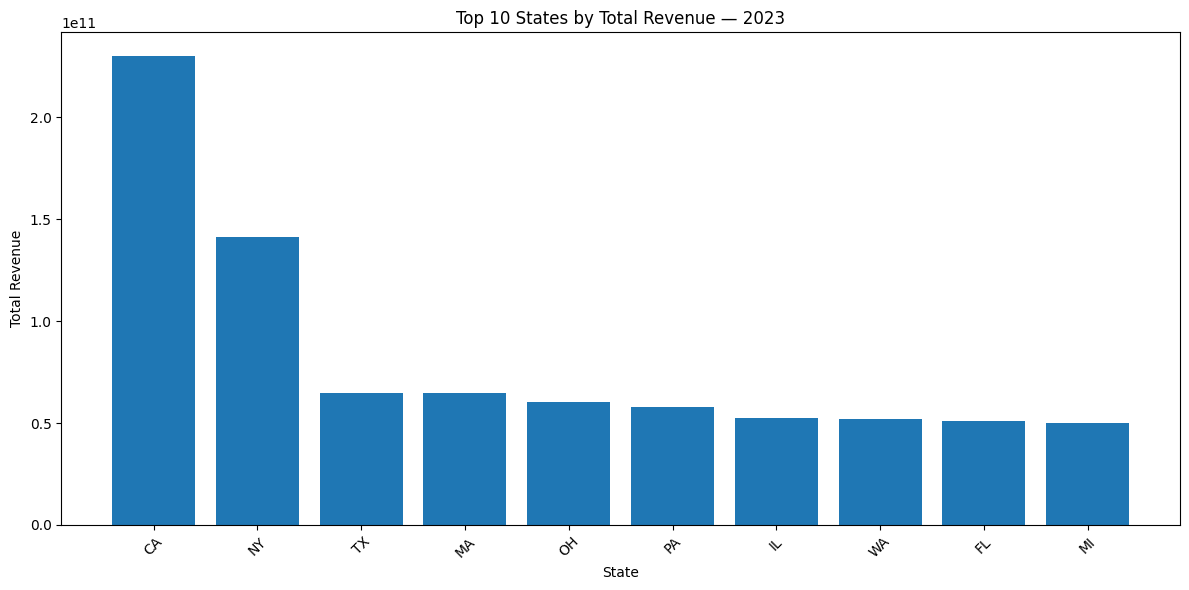

In [26]:
top_states = state_summary.head(10).copy()

plt.figure(figsize=(12, 6))
plt.bar(top_states["state"], top_states["total_revenue"])
plt.title("Top 10 States by Total Revenue — 2023")
plt.xlabel("State")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

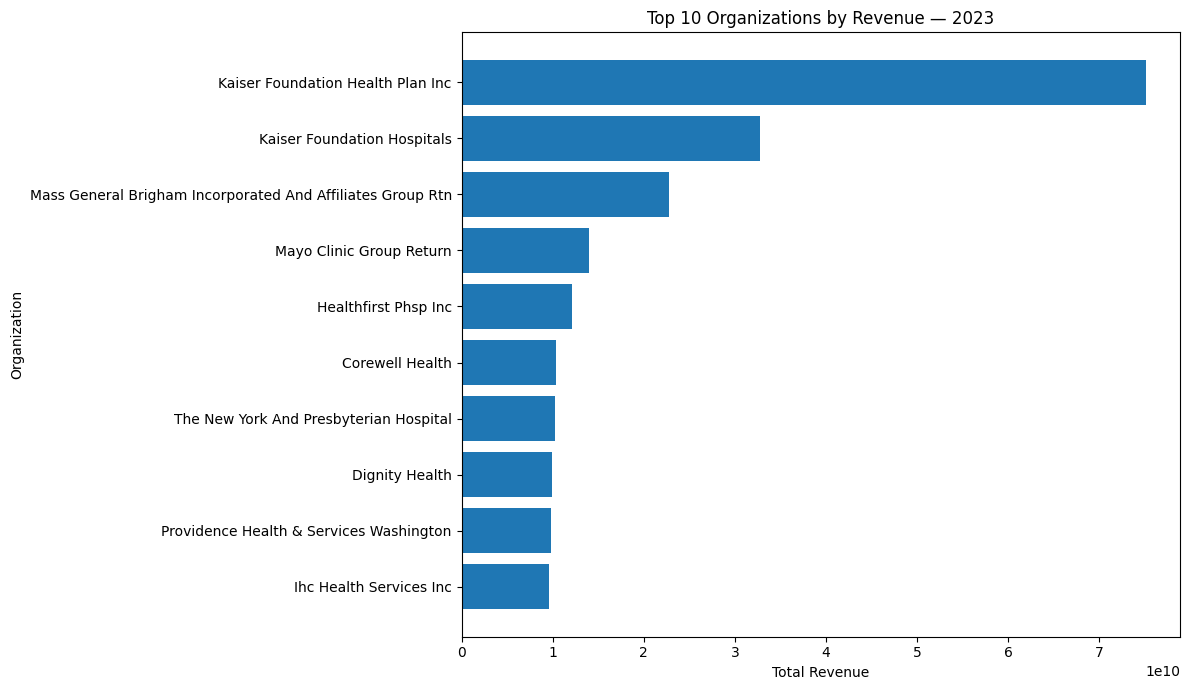

In [27]:
top_orgs_chart = top_revenue_orgs.head(10).copy()

plt.figure(figsize=(12, 7))
plt.barh(top_orgs_chart["org_name"], top_orgs_chart["total_revenue"])
plt.title("Top 10 Organizations by Revenue — 2023")
plt.xlabel("Total Revenue")
plt.ylabel("Organization")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

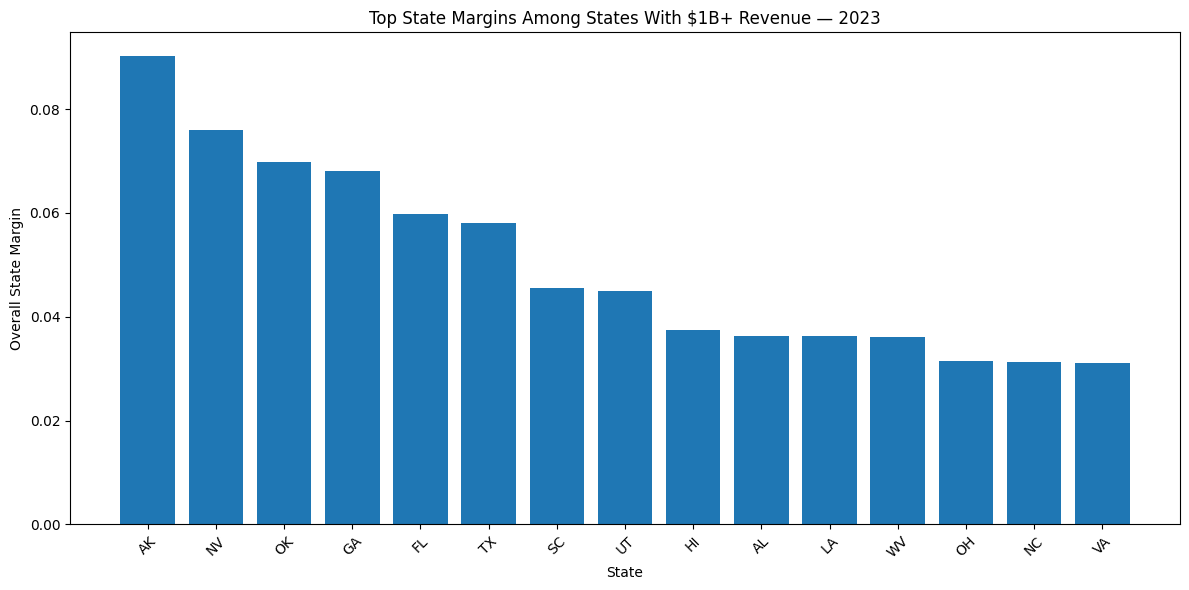

In [28]:
state_margin_chart = state_summary[
    state_summary["total_revenue"] >= 1_000_000_000
].copy()

state_margin_chart = state_margin_chart.sort_values(
    "overall_state_margin",
    ascending=False
).head(15)

plt.figure(figsize=(12, 6))
plt.bar(state_margin_chart["state"], state_margin_chart["overall_state_margin"])
plt.title("Top State Margins Among States With $1B+ Revenue — 2023")
plt.xlabel("State")
plt.ylabel("Overall State Margin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
revenue_concentration = df_2023.sort_values(
    "total_revenue",
    ascending=False
).copy()

revenue_concentration["cumulative_revenue"] = revenue_concentration["total_revenue"].cumsum()

revenue_concentration["cumulative_revenue_share"] = (
    revenue_concentration["cumulative_revenue"] /
    revenue_concentration["total_revenue"].sum()
)

revenue_concentration[[
    "org_name",
    "state",
    "total_revenue",
    "cumulative_revenue_share"
]].head(25)

,org_name,state,total_revenue,cumulative_revenue_share
0,Kaiser Foundation Health Plan Inc,CA,7.510131e+10,0.052278
1,Kaiser Foundation Hospitals,CA,3.278736e+10,0.075101
2,Mass General Brigham Incorporated And Affiliat...,MA,2.273322e+10,0.090926
3,Mayo Clinic Group Return,MN,1.397074e+10,0.100651
4,Healthfirst Phsp Inc,NY,1.208568e+10,0.109063
5,Corewell Health,MI,1.037425e+10,0.116285
6,The New York And Presbyterian Hospital,NY,1.025451e+10,0.123423
7,Dignity Health,AZ,9.914543e+09,0.130325
8,Providence Health & Services Washington,WA,9.778289e+09,0.137131
9,Ihc Health Services Inc,UT,9.638579e+09,0.143841


In [30]:
top_10_share = revenue_concentration.head(10)["total_revenue"].sum() / total_revenue
top_25_share = revenue_concentration.head(25)["total_revenue"].sum() / total_revenue
top_100_share = revenue_concentration.head(100)["total_revenue"].sum() / total_revenue

revenue_share_summary = pd.DataFrame({
    "group": [
        "Top 10 organizations",
        "Top 25 organizations",
        "Top 100 organizations"
    ],
    "revenue_share": [
        top_10_share,
        top_25_share,
        top_100_share
    ]
})

revenue_share_summary

,group,revenue_share
0,Top 10 organizations,0.143841
1,Top 25 organizations,0.223839
2,Top 100 organizations,0.421773


In [32]:
output_file = "nonprofit_health_2023_analysis.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_2023.to_excel(writer, sheet_name="2023 Clean Data", index=False)
    overall_summary.to_excel(writer, sheet_name="Overall Summary", index=False)
    state_summary.to_excel(writer, sheet_name="State Summary", index=False)
    top_revenue_orgs.to_excel(writer, sheet_name="Top Revenue Orgs", index=False)
    top_surplus_orgs.to_excel(writer, sheet_name="Top Surplus Orgs", index=False)
    largest_loss_orgs.to_excel(writer, sheet_name="Largest Loss Orgs", index=False)
    exec_comp_orgs.to_excel(writer, sheet_name="Exec Compensation", index=False)
    comp_ratio_outliers.to_excel(writer, sheet_name="Comp Ratio Outliers", index=False)
    margin_outliers_high.to_excel(writer, sheet_name="High Margin Outliers", index=False)
    margin_outliers_low.to_excel(writer, sheet_name="Low Margin Outliers", index=False)
    data_quality.to_excel(writer, sheet_name="Data Quality", index=False)
    revenue_concentration.to_excel(writer, sheet_name="Revenue Concentration", index=False)
    revenue_share_summary.to_excel(writer, sheet_name="Revenue Share Summary", index=False)

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
pd.options.display.float_format = "{:,.2f}".format

In [34]:
top_surplus_orgs

,ein,org_name,state,total_revenue,total_expenses,surplus,margin
1,941105628,Kaiser Foundation Hospitals,CA,"32,787,361,466.00","30,650,696,643.00","2,136,664,823.00",0.07
12,133971298,Nyu Langone Hospitals,NY,"8,868,510,832.00","7,561,157,803.00","1,307,353,029.00",0.15
2,900656139,Mass General Brigham Incorporated And Affiliat...,MA,"22,733,221,565.00","21,584,405,066.00","1,148,816,499.00",0.05
55,591726273,Orlando Health Inc,FL,"4,224,072,287.00","3,288,156,944.00","935,915,343.00",0.22
9,942854057,Ihc Health Services Inc,UT,"9,638,578,611.00","8,793,797,318.00","844,781,293.00",0.09
10,450233470,Banner Health,AZ,"9,479,573,911.00","8,672,348,619.00","807,225,292.00",0.09
30,351955872,Indiana University Health Inc,IN,"5,752,062,837.00","4,970,388,034.00","781,674,803.00",0.14
0,941340523,Kaiser Foundation Health Plan Inc,CA,"75,101,306,911.00","74,356,004,001.00","745,302,910.00",0.01
50,314394942,Ohiohealth Corporation Grant Riverside Doctors...,OH,"4,522,459,605.00","3,824,186,620.00","698,272,985.00",0.15
16,741152597,Memorial Hermann Health System,TX,"7,581,409,425.00","6,952,309,636.00","629,099,789.00",0.08


In [35]:
!pip install plotly -q

import plotly.express as px
import plotly.graph_objects as go

In [36]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Organizations",
        "Total Revenue",
        "Total Expenses",
        "Total Surplus",
        "Overall Margin"
    ],
    "Value": [
        f"{len(df_2023):,}",
        f"${df_2023['total_revenue'].sum():,.0f}",
        f"${df_2023['total_expenses'].sum():,.0f}",
        f"${df_2023['surplus'].sum():,.0f}",
        f"{(df_2023['surplus'].sum() / df_2023['total_revenue'].sum()):.2%}"
    ]
})

kpi_summary

,Metric,Value
0,Organizations,"16,190"
1,Total Revenue,"$1,436,578,961,186"
2,Total Expenses,"$1,401,646,462,137"
3,Total Surplus,"$34,828,696,872"
4,Overall Margin,2.42%


In [37]:
top_states_revenue = state_summary.head(20).copy()

fig = px.bar(
    top_states_revenue,
    x="state",
    y="total_revenue",
    hover_data=[
        "organizations",
        "total_expenses",
        "total_surplus",
        "overall_state_margin"
    ],
    title="Top 20 States by Total Revenue — 2023",
    labels={
        "state": "State",
        "total_revenue": "Total Revenue",
        "organizations": "Organizations",
        "total_expenses": "Total Expenses",
        "total_surplus": "Total Surplus",
        "overall_state_margin": "State Margin"
    }
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [38]:
state_margin_dashboard = state_summary[
    state_summary["total_revenue"] >= 1_000_000_000
].copy()

state_margin_dashboard = state_margin_dashboard.sort_values(
    "overall_state_margin",
    ascending=False
)

fig = px.bar(
    state_margin_dashboard,
    x="state",
    y="overall_state_margin",
    hover_data=[
        "organizations",
        "total_revenue",
        "total_surplus"
    ],
    title="State Margins for States With $1B+ Revenue — 2023",
    labels={
        "state": "State",
        "overall_state_margin": "Overall State Margin",
        "organizations": "Organizations",
        "total_revenue": "Total Revenue",
        "total_surplus": "Total Surplus"
    }
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [39]:
top_orgs_revenue_dashboard = top_revenue_orgs.head(25).copy()

fig = px.bar(
    top_orgs_revenue_dashboard.sort_values("total_revenue"),
    x="total_revenue",
    y="org_name",
    orientation="h",
    hover_data=[
        "state",
        "total_expenses",
        "surplus",
        "margin",
        "highest_exec_compensation"
    ],
    title="Top 25 Organizations by Revenue — 2023",
    labels={
        "total_revenue": "Total Revenue",
        "org_name": "Organization",
        "state": "State",
        "surplus": "Surplus",
        "margin": "Margin",
        "highest_exec_compensation": "Executive Compensation"
    }
)

fig.show()

In [40]:
largest_loss_dashboard = largest_loss_orgs.head(25).copy()

fig = px.bar(
    largest_loss_dashboard.sort_values("surplus", ascending=False),
    x="surplus",
    y="org_name",
    orientation="h",
    hover_data=[
        "state",
        "total_revenue",
        "total_expenses",
        "margin"
    ],
    title="Largest Loss Organizations — 2023",
    labels={
        "surplus": "Surplus / Loss",
        "org_name": "Organization",
        "state": "State",
        "total_revenue": "Total Revenue",
        "total_expenses": "Total Expenses",
        "margin": "Margin"
    }
)

fig.show()

In [41]:
scatter_data = df_2023[
    (df_2023["total_revenue"] > 0) &
    (df_2023["margin"].notna())
].copy()

fig = px.scatter(
    scatter_data,
    x="total_revenue",
    y="margin",
    size="total_revenue",
    color="state",
    hover_name="org_name",
    hover_data=[
        "ein",
        "total_expenses",
        "surplus",
        "highest_exec_compensation"
    ],
    title="Revenue vs Margin by Organization — 2023",
    labels={
        "total_revenue": "Total Revenue",
        "margin": "Margin",
        "state": "State"
    },
    log_x=True
)

fig.show()

In [42]:
exec_scatter = df_2023[
    (df_2023["total_revenue"] > 0) &
    (df_2023["highest_exec_compensation"].notna())
].copy()

fig = px.scatter(
    exec_scatter,
    x="total_revenue",
    y="highest_exec_compensation",
    color="state",
    size="highest_exec_compensation",
    hover_name="org_name",
    hover_data=[
        "ein",
        "exec_comp_to_revenue",
        "surplus",
        "margin"
    ],
    title="Executive Compensation vs Revenue — 2023",
    labels={
        "total_revenue": "Total Revenue",
        "highest_exec_compensation": "Highest Executive Compensation",
        "exec_comp_to_revenue": "Compensation-to-Revenue"
    },
    log_x=True,
    log_y=True
)

fig.show()

In [43]:
concentration_chart = revenue_concentration.copy()
concentration_chart["rank"] = range(1, len(concentration_chart) + 1)

fig = px.line(
    concentration_chart.head(500),
    x="rank",
    y="cumulative_revenue_share",
    hover_name="org_name",
    hover_data=[
        "state",
        "total_revenue"
    ],
    title="Cumulative Revenue Share by Organization Rank — 2023",
    labels={
        "rank": "Organization Rank by Revenue",
        "cumulative_revenue_share": "Cumulative Revenue Share"
    }
)

fig.show()

In [44]:
import plotly.graph_objects as go

top_table = top_revenue_orgs.head(25).copy()

fig = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=[
                    "EIN",
                    "Organization",
                    "State",
                    "Revenue",
                    "Expenses",
                    "Surplus",
                    "Margin",
                    "Exec Comp"
                ],
                fill_color="lightgray",
                align="left"
            ),
            cells=dict(
                values=[
                    top_table["ein"],
                    top_table["org_name"],
                    top_table["state"],
                    top_table["total_revenue"].map("${:,.0f}".format),
                    top_table["total_expenses"].map("${:,.0f}".format),
                    top_table["surplus"].map("${:,.0f}".format),
                    top_table["margin"].map("{:.2%}".format),
                    top_table["highest_exec_compensation"].fillna(0).map("${:,.0f}".format)
                ],
                align="left"
            )
        )
    ]
)

fig.update_layout(title="Top 25 Organizations by Revenue — 2023")
fig.show()